# Fig. S28 | Distribution of recovery benefits

Shows the evolution, initial recovery gap and spatial concentration of storage benefits during recovery.

In [1]:
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import PchipInterpolator

ROOT=next(p.resolve() for p in [Path.cwd(),*Path.cwd().parents] if (p/'src'/'management').is_dir())
DATA=ROOT/'outputs'/'MANAGEMENT_2012_2013'/'recovery_outcomes'
OUT=ROOT/'outputs'/'figures'/'FigS28'/'FigS28.png'
OUT.parent.mkdir(parents=True,exist_ok=True)
monthly=pd.read_csv(DATA/'unrecovered_monthly.csv',dtype={'seed':str,'month':str})
gaps=pd.read_csv(DATA/'recovery_gap.csv',dtype={'seed':str})
concentration=pd.read_csv(DATA/'benefit_concentration.csv',dtype={'seed':str})
strategies=('Uniform','High pumping','Leverage guided')
labels={'Uniform':'Uniform','High pumping':'High pumping','Leverage guided':'Leverage-guided'}
colors={'Uniform':'#4A4A4A','High pumping':'#7489B5','Leverage guided':'#16857C'}
PI75=1.150349
mpl.rcParams.update({'font.family':'Arial','font.size':10,'axes.labelsize':11.5,'axes.titlesize':11.5,'xtick.labelsize':9,'ytick.labelsize':9,'axes.linewidth':0.75,'axes.spines.top':True,'axes.spines.right':True})

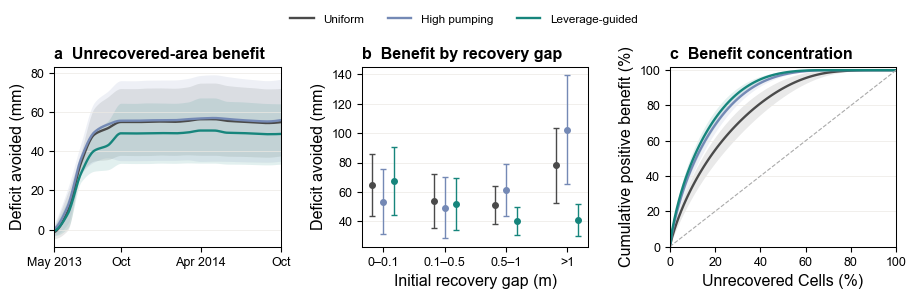

In [2]:
def interval(values):
    values=np.asarray(values,float); mean=values.mean(); radius=PI75*values.std(ddof=0)
    return mean,mean-radius,mean+radius

fig,axes=plt.subplots(1,3,figsize=(9.2,3.0))
for strategy in strategies:
    group=monthly[monthly.strategy.eq(strategy)&monthly.month.le('2014-10')]
    records=[]
    for month,values in group.groupby('month',sort=True): records.append((month,*interval(values.mean_deficit_avoided_m)))
    stats=pd.DataFrame(records,columns=['month','mean','low','high']); x=np.arange(len(stats)); xx=np.linspace(0,len(stats)-1,240)
    smooth=np.column_stack([PchipInterpolator(x,stats[c])(xx) for c in ['mean','low','high']])*1000
    axes[0].plot(xx,smooth[:,0],color=colors[strategy],lw=1.7,label=labels[strategy])
    axes[0].fill_between(xx,smooth[:,1],smooth[:,2],color=colors[strategy],alpha=0.12,lw=0)
axes[0].set_xticks([0,5,11,17],['May 2013','Oct','Apr 2014','Oct']); axes[0].set_xlim(0,17)
axes[0].set(ylabel='Deficit avoided (mm)',title='a  Unrecovered-area benefit')

gap_names=('0-0.1 m','0.1-0.5 m','0.5-1 m','>1 m')
for dx,strategy in zip((-0.18,0,0.18),strategies):
    group=gaps[gaps.endpoint.eq('2013-10')&gaps.strategy.eq(strategy)]
    for x,gap in enumerate(gap_names):
        mean,low,high=interval(1000*group.loc[group.initial_gap.eq(gap),'mean_deficit_avoided_m'])
        axes[1].errorbar(x+dx,mean,yerr=[[mean-low],[high-mean]],fmt='o',color=colors[strategy],ms=4,capsize=2,lw=1)
axes[1].set_xticks(range(4),['0–0.1','0.1–0.5','0.5–1','>1']); axes[1].set(xlabel='Initial recovery gap (m)',ylabel='Deficit avoided (mm)',title='b  Benefit by recovery gap')

for strategy in strategies:
    group=concentration[concentration.endpoint.eq('2013-10')&concentration.strategy.eq(strategy)]
    records=[]
    for area,values in group.groupby('top_area_pct',sort=True): records.append((area,*interval(values.positive_benefit_share)))
    curve=np.vstack([np.zeros(4),np.asarray(records,float)])
    axes[2].plot(curve[:,0],100*curve[:,1],color=colors[strategy],lw=1.7)
    axes[2].fill_between(curve[:,0],100*curve[:,2],100*curve[:,3],color=colors[strategy],alpha=0.12,lw=0)
axes[2].plot([0,100],[0,100],color='#AAAAAA',lw=0.8,ls='--'); axes[2].set(xlim=(0,100),ylim=(0,102),xlabel='Unrecovered Cells (%)',ylabel='Cumulative positive benefit (%)',title='c  Benefit concentration')
for ax in axes:
    ax.title.set_fontweight('bold'); ax.title.set_ha('left'); ax.title.set_position((0,1)); ax.grid(axis='y',color='#ECE9E4',lw=0.5)
handles,names=axes[0].get_legend_handles_labels(); fig.legend(handles,names,loc='upper center',ncol=3,bbox_to_anchor=(0.52,1.01),frameon=False,fontsize=8.5)
fig.subplots_adjust(left=0.075,right=0.99,bottom=0.20,top=0.80,wspace=0.36)
fig.savefig(OUT,dpi=600,bbox_inches='tight',facecolor='white'); plt.show()